In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv(r"C:\\Users\\user\\Documents\\HK2-N2\\LT PYTHON\\movies_final.csv")

In [5]:
# kiểm tra lại dữ liệu 
df.isnull().sum()

name               0
rating             0
year               0
released           0
score              0
votes              0
director           0
writer             0
star               0
country            0
budget             0
gross              0
company            0
runtime            0
Profit             0
genre_Action       0
genre_Adventure    0
genre_Animation    0
genre_Biography    0
genre_Comedy       0
genre_Crime        0
genre_Drama        0
genre_Family       0
genre_Fantasy      0
genre_Horror       0
genre_Mystery      0
genre_Romance      0
genre_Sci-Fi       0
genre_Thriller     0
genre_Western      0
dtype: int64

In [6]:
df.head()

,name,rating,year,released,score,votes,director,writer,star,country,...,genre_Crime,genre_Drama,genre_Family,genre_Fantasy,genre_Horror,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_Western
0,The Shining,R,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,...,False,True,False,False,False,False,False,False,False,False
1,The Blue Lagoon,R,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,...,False,False,False,False,False,False,False,False,False,False
2,Star Wars: Episode V - The Empire Strikes Back,PG,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,...,False,False,False,False,False,False,False,False,False,False
3,Airplane!,PG,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,...,False,False,False,False,False,False,False,False,False,False
4,Caddyshack,R,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,...,False,False,False,False,False,False,False,False,False,False


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5436 entries, 0 to 5435
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             5436 non-null   object 
 1   rating           5436 non-null   object 
 2   year             5436 non-null   int64  
 3   released         5436 non-null   object 
 4   score            5436 non-null   float64
 5   votes            5436 non-null   float64
 6   director         5436 non-null   object 
 7   writer           5436 non-null   object 
 8   star             5436 non-null   object 
 9   country          5436 non-null   object 
 10  budget           5436 non-null   float64
 11  gross            5436 non-null   float64
 12  company          5436 non-null   object 
 13  runtime          5436 non-null   float64
 14  Profit           5436 non-null   float64
 15  genre_Action     5436 non-null   bool   
 16  genre_Adventure  5436 non-null   bool   
 17  genre_Animatio

In [8]:
print(df.columns)

Index(['name', 'rating', 'year', 'released', 'score', 'votes', 'director',
       'writer', 'star', 'country', 'budget', 'gross', 'company', 'runtime',
       'Profit', 'genre_Action', 'genre_Adventure', 'genre_Animation',
       'genre_Biography', 'genre_Comedy', 'genre_Crime', 'genre_Drama',
       'genre_Family', 'genre_Fantasy', 'genre_Horror', 'genre_Mystery',
       'genre_Romance', 'genre_Sci-Fi', 'genre_Thriller', 'genre_Western'],
      dtype='object')


qua kiểm tra sau khi đã hoàn thành làm sạch và chuẩn hóa dữ liệu,ta tiếp tục đi sâu vào việc huấn luyện mô hình để đưa ra dự đoán tốt nhất

In [9]:
# chia biến x,y để bắt đầu xây dựng mô hình
X=df[['budget','votes','runtime','genre_Action', 'genre_Adventure', 'genre_Animation',
       'genre_Biography', 'genre_Comedy', 'genre_Crime', 'genre_Drama',
       'genre_Family', 'genre_Fantasy', 'genre_Horror', 'genre_Mystery',
       'genre_Romance', 'genre_Sci-Fi', 'genre_Thriller', 'genre_Western']]
Y=df[['gross']]

In [10]:
# chia tập train và test để huấn luyện mô hình
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(
    X,Y,   # x,y là biến đầu vào đã phân loại trước đó
    test_size=0.2,  # chọn 20% dữ liệu để làm test
    random_state=42 # chia dữ liệu ngẫu nhiên
)

Vì dự đoán doanh thu phim là một dữ liệu gồm nhiều biến khác nhau,nên ta sẽ dùng nhiều MH để dự đoán nhằm đưa ra kết quả tốt nhất

In [11]:
# thực hiện việc phân chia các mô hình để thực hiện mô hình dự đoán
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor

Các khái niệm :
Decision Tree : 
- phân loại và dự đoán giá trị số bằng cách chia dữ liệu thành các nhánh dựa trên điều kiện
- Mô hình cấu trúc giống như một cái cây,chia dữ liệu thành nhiều nhóm nhỏ thông qua các nguyên tắc quyết định và dựa vào đó đưa ra kết quả
Hoạt động theo quy tắc:
- Chọn thuộc tính tốt nhất để chia dữ liệu
-Chia dataset thành các nhóm nhỏ.Lặp lại quá trình cho từng nhóm
- Kết thúc khi dữ liệu đủ thuần thục và đạt được độ sâu tối đa
Linear Regression:
- Tìm đường thẳng tốt nhất mô tả mối quan hệ giữa các biến
- Bởi pt hồi quy tuyến tính bội: y=b0 + b1x+b2x
- Tìm đường thẳng sao cho sai số nhỏ nhất giữa giá trị dự đoán và giá trị thật
Random Forest Regression:
- Là một thuật toán học máy dùng để dự đoán giá trị số liên tục bằng cách kết hợp nhiều cây quyết định và lấy trung bình kết quả dự đoán của các cây.
- Tạo ra nhiều quyết định từ các kết quả ngẫu nhiên
- Mỗi cây sẽ đưa ra một giá trị dự đoán và kết quả cuối cùng là trung bình cho các dự đoán đó
Gradient Boosting:
- Là một thuật toán kết hợp nhiều mô hình yếu (thường là cây quyết định nhỏ) nhằm tạo ra mô hình có khả năng dự đoán chính xác hơn
- Giúp xây dựng tuần tự và kết hợp nhiều mô hình yếu.
- Khởi tạo mô hình đầu tiên và dự đoán bằng giá trị trung bình của biến mục tiêu
- Dự đoán bằng giá trị trung bình của biến mục tiêu


Dùng cross validation tìm mô hình tốt nhất là pp đánh giá độ chính xác của mô hình học máy bằng cách chia dữ liệu thành  nhiều phần và huấn luyện và kiểm tra mô hình nhiều lần 

Mục đích của Cross validation:
 
 - Là khả năng tổng quát của mô hình
 - Giảm hiện tượng overfiting
Quy trình: 

  -Chia dữ liệu thành k phần (fold).
  -Lặp lại k lần huấn luyện:Mỗi lần chọn 1 phần làm tập test k-1 phần còn lại làm tập train
  -Tính độ chính xác trung bình của k lần.

In [12]:
# tạo thư viện chứa các mô hình 
models={
    "Linear Regression":LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regression": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor()
}
from sklearn.model_selection import cross_val_score
results={} # dùng để lưu kết quả
for name,model in models.items(): 
    scores=cross_val_score( # hàm dùng để thực hiện 
        model,
        X_train,
        Y_train,
        cv=5,
        scoring="r2" # dùng chỉ số r2 để đánh giá độ chính xác cao nhất
    )
    results[name]=scores.mean() 

print(results)
results_df=pd.DataFrame(list(results.items()),columns=["model","R2 score"])
print(results_df)

c:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for exa

{'Linear Regression': np.float64(0.6364049479511347), 'Decision Tree': np.float64(0.32381407688104263), 'Random Forest Regression': np.float64(0.6611851019469602), 'Gradient Boosting': np.float64(0.6650190366658706)}
                      model  R2 score
0         Linear Regression  0.636405
1             Decision Tree  0.323814
2  Random Forest Regression  0.661185
3         Gradient Boosting  0.665019


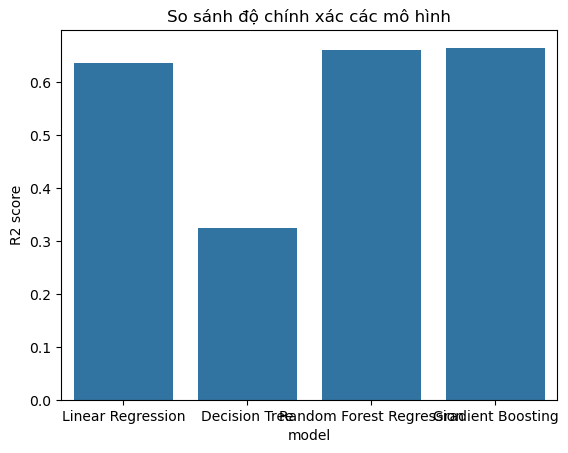

In [13]:
# mô hình so sánh
plt.Figure(figsize=(8,5))
sns.barplot(
    x="model",
    y="R2 score",
    data=results_df
)
plt.title("So sánh độ chính xác các mô hình")
plt.show()

Chia dữ liệu thành 5 phần và lấy kết quả trung bình sau 5 lần thử ở các model
Giúp ta thử được nhiều mô hình khác nhau và đánh giá được công bằng nhất


Dựa vào kết quả chạy , chọn mô hình có kết quả tốt nhất là gradient boosting

In [14]:
best_model=GradientBoostingRegressor()
best_model.fit(X_train,Y_train)
pred=best_model.predict(X_test)

# đánh giá mô hình bằng các chỉ số:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(Y_test, pred)

mse = mean_squared_error(Y_test, pred)
rmse = np.sqrt(mse)

print("====Chỉ số mô hình=====")
print("R2:", r2)
print("RMSE:", rmse)

c:\Users\user\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


====Chỉ số mô hình=====
R2: 0.76293027464696
RMSE: 98717083.15437333


Chọn được model có kết quả chính xác nhất

In [15]:
best_model.fit(X_train,Y_train)


c:\Users\user\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [16]:
import joblib
joblib.dump(best_model,"movie_model.pkl")

['movie_model.pkl']

In [17]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']